In [ ]:
!pip install nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')

print("All libraries loaded!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


All libraries loaded!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload IMDB Dataset.csv

df = pd.read_csv('IMDB Dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
print(f"\nSample review:")
print(df['review'][0][:300])

Saving IMDB Dataset.csv to IMDB Dataset.csv
Dataset shape: (50000, 2)

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru


In [ ]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Negation-safe stop words — keep NOT words!
stop_words = set(stopwords.words('english'))
negation_words = {'no', 'not', 'nor', 'neither', 'never',
                  'nothing', 'nobody', 'nowhere', 'hardly',
                  'barely', 'scarcely', "don't", "won't",
                  "can't", "isn't", "aren't", "wasn't",
                  "weren't", "hasn't", "haven't", "hadn't"}
stop_words = stop_words - negation_words

def preprocess_text(text):
    # Step 1: Remove HTML tags (e.g. <br>)
    text = re.sub(r'<.*?>', ' ', text)

    # Step 2: Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 3: Lowercase
    text = text.lower()

    # Step 4: Tokenize
    tokens = word_tokenize(text)

    # Step 5: Remove stop words (negation-safe)
    tokens = [t for t in tokens if t not in stop_words]

    # Step 6: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

print("Testing preprocessor...")
sample = df['review'][0]
print(f"\nBefore: {sample[:200]}")
print(f"\nAfter:  {preprocess_text(sample)[:200]}")

Testing preprocessor...

Before: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

After:  one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust not show faint hearted timid show pull


In [ ]:
print("Preprocessing 50,000 reviews — takes 2-3 minutes...")

df['clean_review'] = df['review'].apply(preprocess_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Done! Shape: {df.shape}")
print(f"\nSample clean review:")
print(df['clean_review'][0][:300])

Preprocessing 50,000 reviews — takes 2-3 minutes...
Done! Shape: (50000, 4)

Sample clean review:
one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust not show faint hearted timid show pull no punch regard drug sex violence hardcore classic use word called oz nickname given oswald maximum


In [ ]:
# Split data FIRST
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

# TF-IDF with unigrams + bigrams
tfidf = TfidfVectorizer(
    max_features=10000,        # top 10K features
    ngram_range=(1, 2),        # unigrams + bigrams
    min_df=5,                  # ignore rare terms
    sublinear_tf=True          # log normalization
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"Sparse matrix type:  {type(X_train_tfidf)}")
print(f"Memory efficient:    CSR format ✓")

Training set: (40000,)
Testing set:  (10000,)

TF-IDF matrix shape: (40000, 10000)
Sparse matrix type:  <class 'scipy.sparse._csr.csr_matrix'>
Memory efficient:    CSR format ✓


In [ ]:
# Train MultinomialNB
print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred = nb_model.predict(X_test_tfidf)

# Evaluate
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"\n{'='*45}")
print(f"  SENTIMENT ANALYSIS RESULTS")
print(f"{'='*45}")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"{'='*45}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Positive']))

Training Multinomial Naive Bayes...

  SENTIMENT ANALYSIS RESULTS
  Accuracy  : 0.8720
  Precision : 0.8613
  Recall    : 0.8868
  F1 Score  : 0.8739

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      5000
    Positive       0.86      0.89      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



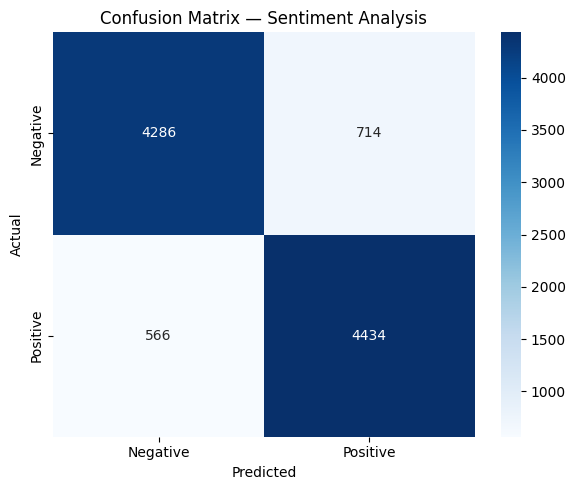

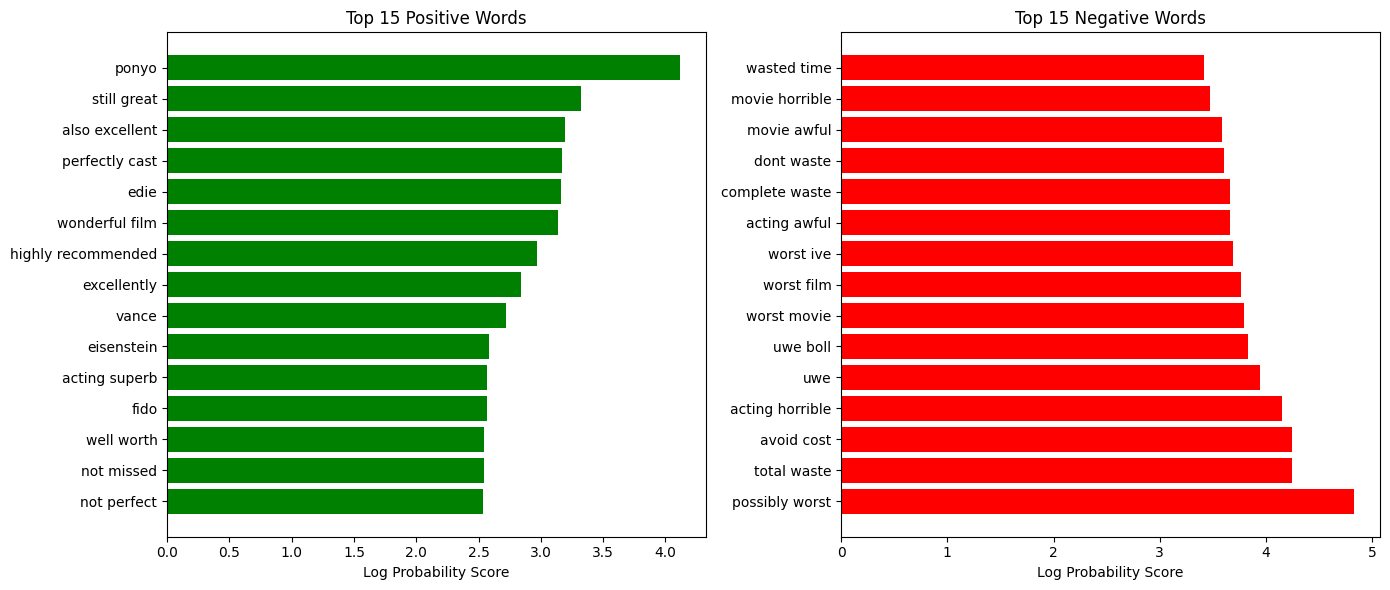

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Sentiment Analysis')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Top positive & negative words
feature_names = tfidf.get_feature_names_out()
coefs = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]

top_positive = pd.DataFrame({
    'word': feature_names[np.argsort(coefs)[-15:]],
    'score': coefs[np.argsort(coefs)[-15:]]
})

top_negative = pd.DataFrame({
    'word': feature_names[np.argsort(coefs)[:15]],
    'score': coefs[np.argsort(coefs)[:15]]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_positive['word'], top_positive['score'], color='green')
axes[0].set_title('Top 15 Positive Words')
axes[0].set_xlabel('Log Probability Score')

axes[1].barh(top_negative['word'], abs(top_negative['score']), color='red')
axes[1].set_title('Top 15 Negative Words')
axes[1].set_xlabel('Log Probability Score')

plt.tight_layout()
plt.show()

In [ ]:
def predict_sentiment(review):
    clean = preprocess_text(review)
    vector = tfidf.transform([clean])
    pred = nb_model.predict(vector)[0]
    prob = nb_model.predict_proba(vector)[0]

    sentiment = "POSITIVE" if pred == 1 else "NEGATIVE"
    confidence = max(prob) * 100

    print(f"Review: {review[:100]}...")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.2f}%")
    return sentiment

# Test it!
predict_sentiment("This movie was absolutely amazing! Best film I've seen.")
predict_sentiment("Terrible movie, complete waste of time. Not worth watching.")
predict_sentiment("Not bad but could have been better. Average film overall.")

Review: This movie was absolutely amazing! Best film I've seen....
Sentiment: POSITIVE
Confidence: 67.25%
Review: Terrible movie, complete waste of time. Not worth watching....
Sentiment: NEGATIVE
Confidence: 99.75%
Review: Not bad but could have been better. Average film overall....
Sentiment: NEGATIVE
Confidence: 71.97%


'NEGATIVE'

In [ ]:
import pickle

# Save model and vectorizer
with open('nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save results
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Score':  [accuracy, precision, recall, f1]
})
results.to_csv('sentiment_results.csv', index=False)

from google.colab import files
files.download('sentiment_results.csv')
print("All saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All saved!
